# <font color="#418FDE" size="6.5" uppercase>**Time-Series Preprocessing**</font>

>Last update: 20260419.
    
By the end of this Lecture, you will be able to:
- Resample irregular civil engineering time-series data to a regular time grid while handling missing values appropriately. 
- Engineer rolling window features such as moving averages and rates of change for temporal civil engineering signals. 
- Implement time-aware train-validation splits that respect temporal order and avoid leakage. 


## **1. Irregular Time Resampling**

### **1.1. Time Indexing**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_01_01.jpg?v=1776653478" width="250">



>* Time indexing organizes irregular measurements in time.
>* Consistent timestamps enable sorting and resampling.

>* Timestamps must reflect instants or intervals.
>* Standardize times to avoid resampling errors.

>* Time indexing reveals gaps and true spacing.
>* It aligns datasets for accurate regular resampling.



--2026-04-19 23:13:30--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.1’

AirQualityUCI.zip.1     [  <=>               ]   1.47M  3.99MB/s    in 0.4s    

2026-04-19 23:13:31 (3.99 MB/s) - ‘AirQualityUCI.zip.1’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
Rows after indexing: 9357
Time range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Index meaning: each row timestamp marks one observation time.
Sampling minutes min/median/max:
min    60.0
50%    60.0
max    60.0


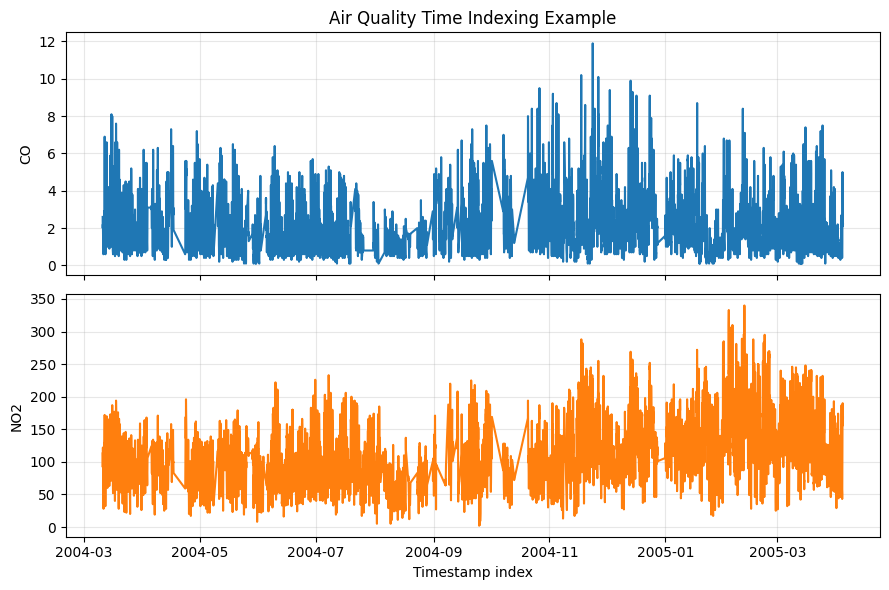

In [2]:
#@title Python Code - Time Indexing

# This example teaches careful timestamp indexing.
# Air quality data supports environmental monitoring.
# We build and inspect a datetime index.

# !pip install pandas matplotlib numpy

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Import beginner friendly libraries.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Load the semicolon separated file.
file_name = "AirQualityUCI.csv"
df = pd.read_csv(file_name, sep=";", decimal=",")

# Remove empty unnamed columns.
df = df.dropna(axis=1, how="all")
df.columns = df.columns.str.strip()

# Combine date and time text.
datetime_text = df["Date"] + " " + df["Time"]
df["timestamp"] = pd.to_datetime(

    datetime_text,
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce")

# Keep rows with valid timestamps.
df = df.dropna(subset=["timestamp"])
df = df.sort_values("timestamp")

# Build the datetime index.
df = df.set_index("timestamp")
df = df[~df.index.duplicated(keep="first")]

# Replace dataset missing value code.
df = df.replace(-200, np.nan)
co_col = "CO(GT)"

no2_col = "NO2(GT)"

# Compute sampling interval summary.
step = df.index.to_series().diff().dropna()
minutes = step.dt.total_seconds() / 60.0

interval_summary = minutes.describe()[["min", "50%", "max"]]

# Print a short teaching summary.
print("Rows after indexing:", len(df))
print("Time range:", df.index.min(), "to", df.index.max())

print("Index meaning: each row timestamp marks one observation time.")
print("Sampling minutes min/median/max:")
print(interval_summary.round(1).to_string())

# Select two environmental variables.
plot_df = df[[co_col, no2_col]].copy()
plot_df = plot_df.interpolate(limit_direction="both")

# Create one clear time series figure.
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(plot_df.index, plot_df[co_col], color="tab:blue")

axes[0].set_ylabel("CO")
axes[0].set_title("Air Quality Time Indexing Example")

# Plot the second monitoring variable.
axes[1].plot(plot_df.index, plot_df[no2_col], color="tab:orange")
axes[1].set_ylabel("NO2")

axes[1].set_xlabel("Timestamp index")

# Improve plot readability.
for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **1.2. Sampling Gaps**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_01_02.jpg?v=1776653565" width="250">



>* Monitoring systems often contain missing time periods.
>* Resampling reveals gaps that affect analysis.

>* Fill gaps based on physical context.
>* Long volatile gaps need cautious treatment.

>* Filled gaps can falsely suggest complete data.
>* Document gaps and preserve uncertainty transparently.



Irregular spacing example in hours:
datetime
1.0    82
2.0     1
3.0     1
4.0     2
Name: count, dtype: int64

Comparison at selected missing timestamps:
                     original  irregular  leave_missing  forward_fill  interpolated
datetime                                                                           
2004-03-15 04:00:00       NaN        NaN            NaN           1.1          1.05
2004-03-15 08:00:00       5.5        NaN            NaN           2.2          2.70
2004-03-15 09:00:00       8.1        NaN            NaN           2.2          3.20
2004-03-15 10:00:00       5.8        NaN            NaN           NaN           NaN
2004-03-16 04:00:00       NaN        NaN            NaN           0.7          0.65
2004-03-16 14:00:00       3.8        NaN            NaN           4.0          3.63

Forward fill suits short stable gaps.
Interpolation suits smooth changing signals.
Leave critical event gaps as missing.


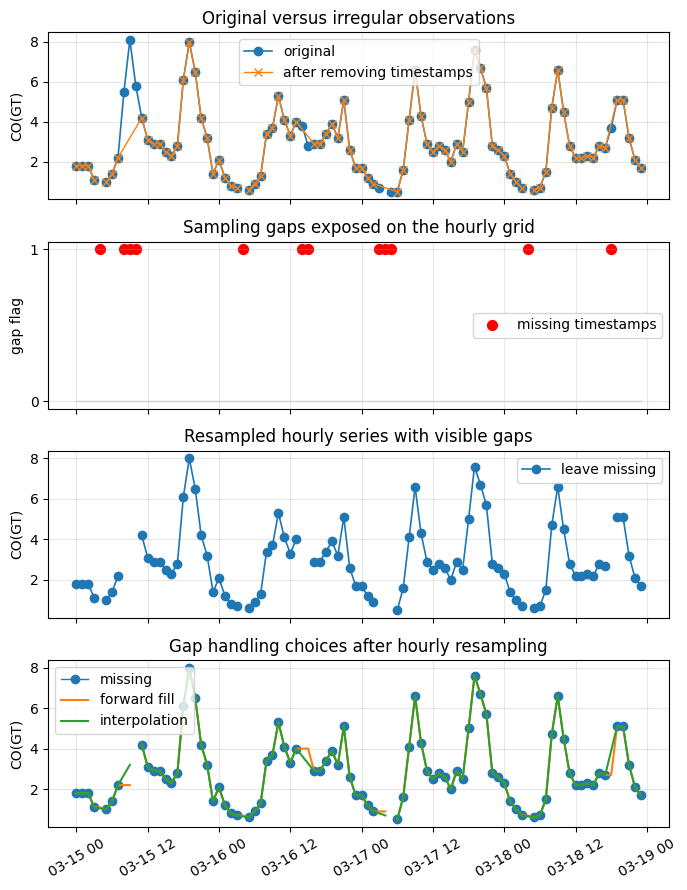

In [3]:
#@title Python Code - Sampling Gaps

# Explore sampling gaps in sensor records.
# Use air quality data for resampling.
# Compare simple gap handling choices.

# Download the dataset in Colab first.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

import os
import zipfile
import random

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

# Set seeds for reproducible gaps.
random.seed(7)
np.random.seed(7)

# Check that the zip file exists.
zip_path = "AirQualityUCI.zip"
if not os.path.exists(zip_path):

    raise FileNotFoundError(
        "Run the wget cell first.")

# Extract the dataset safely.
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall("air_quality_data")

# Build the csv file path.
csv_path = os.path.join(
    "air_quality_data", "AirQualityUCI.csv")

# Load the semicolon separated file.
df = pd.read_csv(
    csv_path,

    sep=";",
    decimal=",")

# Remove empty trailing columns.
df = df.dropna(axis=1, how="all")

# Combine date and time columns.
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],

    format="%d/%m/%Y %H.%M.%S",
    errors="coerce")

# Replace dataset missing codes.
df = df.replace(-200, np.nan)

# Keep one useful sensor signal.
series = df[["datetime", "CO(GT)"]].copy()
series = series.dropna(subset=["datetime"])

series = series.sort_values("datetime")
series = series.set_index("datetime")

# Remove duplicate timestamps if any.
series = series[~series.index.duplicated(keep="first")]

# Keep a short teaching window.
start_time = "2004-03-15 00:00:00"
end_time = "2004-03-18 23:00:00"

series = series.loc[start_time:end_time].copy()

# Validate that enough rows exist.
if len(series) < 48:
    raise ValueError("Selected window is too small.")

# Create a regular reference grid.
full_grid = pd.date_range(
    series.index.min(),

    series.index.max(),
    freq="h")

# Simulate irregular sampling gaps.
remove_times = pd.to_datetime([
    "2004-03-15 08:00:00",

    "2004-03-15 09:00:00",
    "2004-03-15 10:00:00",
    "2004-03-16 14:00:00",

    "2004-03-16 15:00:00",
    "2004-03-17 03:00:00",
    "2004-03-17 04:00:00",

    "2004-03-17 05:00:00",
    "2004-03-18 18:00:00"])

# Drop selected timestamps to create gaps.
irregular = series.drop(remove_times, errors="ignore")

# Measure irregular time spacing.
delta_hours = irregular.index.to_series().diff()
delta_hours = delta_hours.dt.total_seconds() / 3600.0

# Resample back to a regular hourly grid.
regular = irregular.resample("h").mean()
regular = regular.reindex(full_grid)

regular.index.name = "datetime"

# Create several gap handling versions.
leave_missing = regular.copy()
forward_fill = regular.ffill(limit=2)

interpolated = regular.interpolate(method="time", limit=2)

# Mark which timestamps were missing.
gap_mask = leave_missing["CO(GT)"].isna()
missing_times = leave_missing.index[gap_mask]

# Build a small comparison table.
comparison = pd.DataFrame({
    "original": series.reindex(full_grid)["CO(GT)"],

    "irregular": irregular.reindex(full_grid)["CO(GT)"],
    "leave_missing": leave_missing["CO(GT)"],
    "forward_fill": forward_fill["CO(GT)"],

    "interpolated": interpolated["CO(GT)"]})

# Show a compact summary table.
summary_rows = comparison.loc[missing_times].head(6)
print("Irregular spacing example in hours:")

print(delta_hours.dropna().value_counts().sort_index().head())
print()
print("Comparison at selected missing timestamps:")

print(summary_rows.round(2).to_string())
print()
print("Forward fill suits short stable gaps.")

print("Interpolation suits smooth changing signals.")
print("Leave critical event gaps as missing.")

# Create one figure with four panels.
fig, axes = plt.subplots(4, 1, figsize=(7, 9), sharex=True)

# Plot the original and irregular series.
axes[0].plot(
    series.index,

    series["CO(GT)"],
    marker="o",
    linewidth=1.2,

    label="original")
axes[0].plot(
    irregular.index,

    irregular["CO(GT)"],
    marker="x",
    linewidth=1.0,

    label="after removing timestamps")
axes[0].set_title("Original versus irregular observations")
axes[0].set_ylabel("CO(GT)")

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot the gap locations clearly.
axes[1].plot(
    leave_missing.index,

    np.zeros(len(leave_missing.index)),
    color="lightgray",
    linewidth=1.0)

axes[1].scatter(
    missing_times,
    np.ones(len(missing_times)),

    color="red",
    s=50,
    label="missing timestamps")

axes[1].set_title("Sampling gaps exposed on the hourly grid")
axes[1].set_ylabel("gap flag")
axes[1].set_yticks([0, 1])

axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot the regular grid with missing values.
axes[2].plot(
    leave_missing.index,

    leave_missing["CO(GT)"],
    marker="o",
    linewidth=1.2,

    label="leave missing")
axes[2].set_title("Resampled hourly series with visible gaps")
axes[2].set_ylabel("CO(GT)")

axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot the filling choices together.
axes[3].plot(
    leave_missing.index,

    leave_missing["CO(GT)"],
    marker="o",
    linewidth=1.0,

    label="missing")
axes[3].plot(
    forward_fill.index,

    forward_fill["CO(GT)"],
    linewidth=1.5,
    label="forward fill")

axes[3].plot(
    interpolated.index,
    interpolated["CO(GT)"],

    linewidth=1.5,
    label="interpolation")
axes[3].set_title("Gap handling choices after hourly resampling")

axes[3].set_ylabel("CO(GT)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Finish the figure neatly.
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

### **1.3. Aligning Sensor Streams**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_01_03.jpg?v=1776653611" width="250">



>* Sensors need a shared timeline.
>* Resample streams onto a common grid.

>* Choose interpolation based on signal behavior.
>* Verify timestamps truly match across sensors.

>* Aligned streams reveal reliable cross-sensor patterns.
>* Keep missing gaps visible after resampling.



--2026-04-19 23:13:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.2’

AirQualityUCI.zip.2     [  <=>               ]   1.47M  4.02MB/s    in 0.4s    

2026-04-19 23:13:33 (4.02 MB/s) - ‘AirQualityUCI.zip.2’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Aligned rows and columns: (5115, 6)
Columns are simultaneous sensor variables.
Train samples: 4089 Validation samples: 1023
Validation MAE: 0.347 R2: 0.82


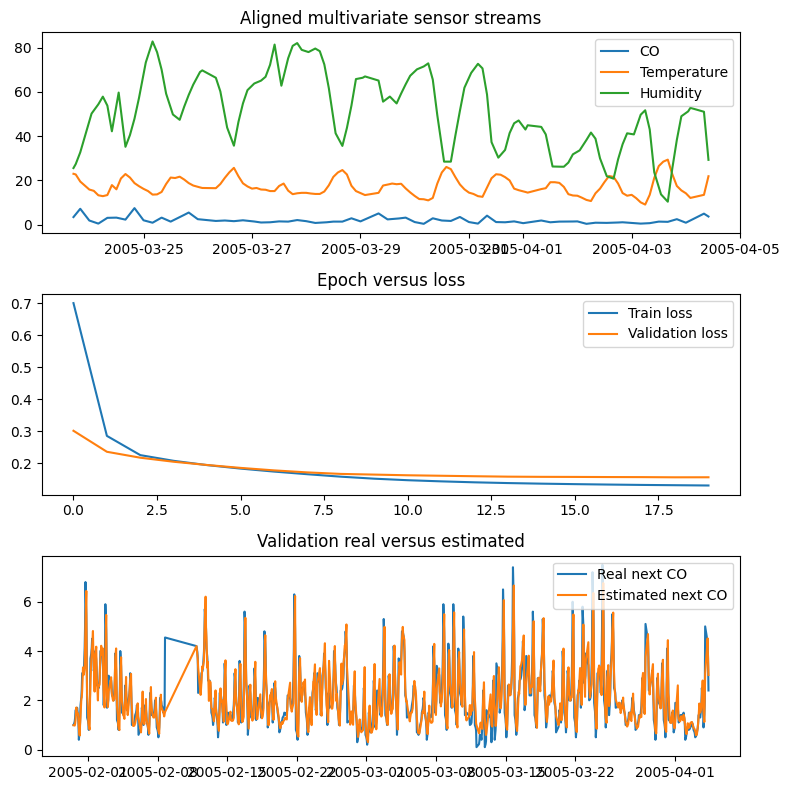

In [4]:
#@title Python Code - Aligning Sensor Streams

# Align sensor streams on one timeline.
# Build simple features from resampled signals.
# Predict one step ahead target.

# !pip install tensorflow==2.20.0

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

!unzip -o AirQualityUCI.zip

# Import quiet and essential libraries.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, r2_score

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show TensorFlow version briefly.
print('TensorFlow version:', tf.__version__)

# Load the air quality table.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

extra_cols = ['Unnamed: 15', 'Unnamed: 16']
df = df.drop(columns=extra_cols, errors='ignore')

# Combine date and time columns.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace dataset missing value code.
df = df.replace(-200, np.nan)
df = df.dropna(subset=['DateTime'])

df = df.sort_values('DateTime')
df = df.set_index('DateTime')

# Keep useful aligned sensor streams.
cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',

    'NOx(GT)', 'PT08.S4(NO2)', 'T', 'RH', 'AH']

data = df[cols].copy()

# Create irregular streams by dropping rows.
stream_a = data[['PT08.S1(CO)', 'T']].iloc[::2].copy()
stream_b = data[['RH', 'AH']].iloc[1::3].copy()

stream_c = data[['CO(GT)', 'NOx(GT)']].iloc[2::4].copy()

# Resample each stream to hourly grid.
stream_a = stream_a.resample('1h').mean()
stream_b = stream_b.resample('1h').mean()

stream_c = stream_c.resample('1h').mean()
stream_a = stream_a.interpolate(limit=2)
stream_b = stream_b.interpolate(limit=2)

stream_c = stream_c.interpolate(limit=2)

# Align all streams on one index.
aligned = pd.concat([stream_a, stream_b, stream_c], axis=1)
aligned = aligned.sort_index()

aligned = aligned.dropna()

# Explain multivariate table shape.
print('Aligned rows and columns:', aligned.shape)
print('Columns are simultaneous sensor variables.')

# Create one step ahead target.
aligned['target_next_CO'] = aligned['CO(GT)'].shift(-1)
aligned['CO_change_1h'] = aligned['CO(GT)'].diff()

aligned['temp_mean_3h'] = aligned['T'].rolling(3).mean()
aligned = aligned.dropna()

# Prepare features and target arrays.
feature_cols = [
    'PT08.S1(CO)', 'T', 'RH', 'AH',

    'CO(GT)', 'NOx(GT)', 'CO_change_1h', 'temp_mean_3h']
X = aligned[feature_cols].to_numpy(dtype='float32')
y = aligned['target_next_CO'].to_numpy(dtype='float32')

# Make chronological train validation split.
n_total = len(aligned)
train_end = int(n_total * 0.8)

X_train = X[:train_end]
X_val = X[train_end:]
y_train = y[:train_end]

y_val = y[train_end:]

# Scale using training statistics only.
mean_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0) + 1e-6

mean_y = y_train.mean()
std_y = y_train.std() + 1e-6
X_train = (X_train - mean_x) / std_x

X_val = (X_val - mean_x) / std_x
y_train_s = (y_train - mean_y) / std_y
y_val_s = (y_val - mean_y) / std_y

# Check sizes before training.
print('Train samples:', len(X_train), 'Validation samples:', len(X_val))
if len(X_train) < 20 or len(X_val) < 10:

    raise ValueError('Not enough aligned samples.')

# Build a tiny dense model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile and train quietly.
model.compile(optimizer='adam', loss='mse')
history = model.fit(

    X_train, y_train_s,
    validation_data=(X_val, y_val_s),
    epochs=20, batch_size=32, verbose=0)

# Predict on validation period.
pred_s = model.predict(X_val, verbose=0).reshape(-1)
pred = pred_s * std_y + mean_y

mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)
print('Validation MAE:', round(float(mae), 3), 'R2:', round(float(r2), 3))

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
axes[0].plot(aligned.index[-200:], aligned['CO(GT)'].tail(200), label='CO')

axes[0].plot(aligned.index[-200:], aligned['T'].tail(200), label='Temperature')
axes[0].plot(aligned.index[-200:], aligned['RH'].tail(200), label='Humidity')
axes[0].set_title('Aligned multivariate sensor streams')

axes[0].legend(loc='upper right')

axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Epoch versus loss')

axes[1].legend(loc='upper right')

val_index = aligned.index[train_end:train_end + len(y_val)]
axes[2].plot(val_index, y_val, label='Real next CO')
axes[2].plot(val_index, pred, label='Estimated next CO')

axes[2].set_title('Validation real versus estimated')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## **2. Rolling Window Features**

### **2.1. Moving Average Trends**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_02_01.jpg?v=1776653785" width="250">



>* Moving averages smooth noisy engineering signals.
>* They reveal trends for monitoring and modelling.

>* Window length sets trend timescale.
>* Compare windows to balance noise and detail.

>* Moving averages improve forecasting and condition assessment.
>* Align rolling windows with prediction timing.



--2026-04-19 23:13:41--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.3’

AirQualityUCI.zip.3     [  <=>               ]   1.47M  3.94MB/s    in 0.4s    

2026-04-19 23:13:42 (3.94 MB/s) - ‘AirQualityUCI.zip.3’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Rows used: 2964
Features used: NO2(GT), ma_3, ma_12, ma_24, roc_1
Test MAE: 17.67


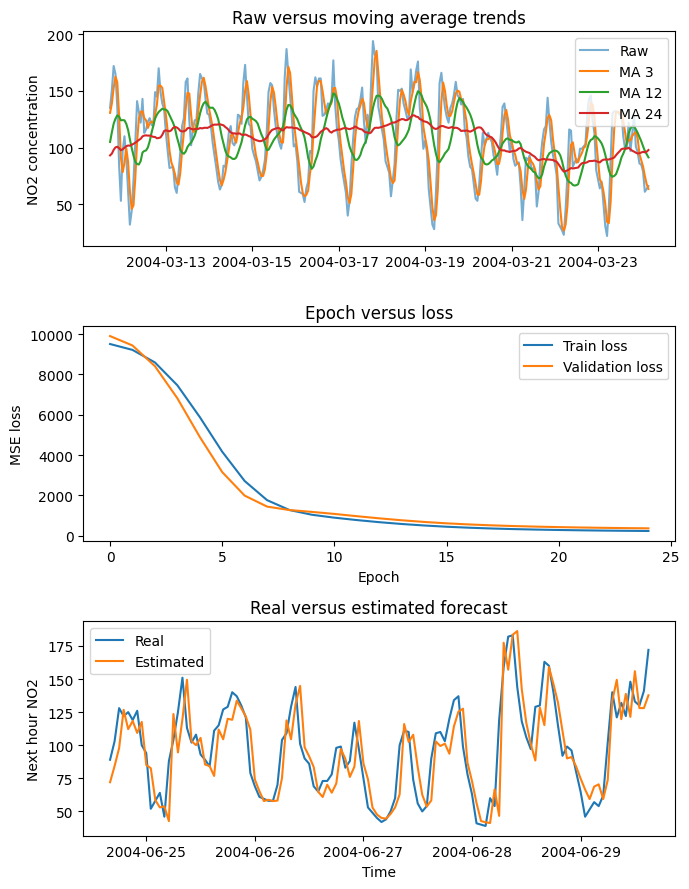

In [5]:
#@title Python Code - Moving Average Trends

# This example studies moving average trends.
# Air quality data supports civil monitoring ideas.
# Rolling features help forecast noisy pollutant signals.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Silence TensorFlow warnings for beginners.
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

print('TensorFlow version:', tf.__version__)

# Load the air quality table.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

# Remove empty unnamed columns.
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')

# Build a proper timestamp column.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Keep one pollutant for smoothing.
pollutant = 'NO2(GT)'
df[pollutant] = pd.to_numeric(df[pollutant], errors='coerce')

# Replace dataset missing value code.
df[pollutant] = df[pollutant].replace(-200, np.nan)
df = df[['DateTime', pollutant]].dropna().sort_values('DateTime')

# Keep a manageable continuous subset.
df = df.iloc[:2500].copy()
df = df.set_index('DateTime').asfreq('h')

# Fill occasional gaps smoothly.
df[pollutant] = df[pollutant].interpolate(limit_direction='both')
df[pollutant] = df[pollutant].ffill().bfill()

# Create moving average trend features.
df['ma_3'] = df[pollutant].rolling(3).mean()
df['ma_12'] = df[pollutant].rolling(12).mean()

df['ma_24'] = df[pollutant].rolling(24).mean()

# Create a simple rate feature.
df['roc_1'] = df[pollutant].pct_change()
df['target_next'] = df[pollutant].shift(-1)

# Remove rows with incomplete windows.
df = df.dropna().copy()

# Prepare feature and target arrays.
feature_cols = [pollutant, 'ma_3', 'ma_12', 'ma_24', 'roc_1']
X = df[feature_cols].to_numpy(dtype='float32')

y = df['target_next'].to_numpy(dtype='float32')

# Split chronologically to avoid leakage.
n_total = len(df)
train_end = int(n_total * 0.7)

val_end = int(n_total * 0.85)

# Slice train validation test sets.
X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

# Slice the final test set.
X_test = X[val_end:]
y_test = y[val_end:]

test_time = df.index[val_end:]

# Check that splits are usable.
if len(X_train) < 50 or len(X_test) < 20:
    raise ValueError('Dataset split is too small.')

# Standardize using training statistics.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-6

# Apply the same scaling everywhere.
X_train_s = (X_train - train_mean) / train_std
X_val_s = (X_val - train_mean) / train_std

X_test_s = (X_test - train_mean) / train_std

# Build a small dense forecasting model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_s.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the regression model.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Train quietly with validation tracking.
history = model.fit(
    X_train_s, y_train,

    validation_data=(X_val_s, y_val),
    epochs=25,
    batch_size=32,

    verbose=0)

# Predict the future pollutant values.
y_pred = model.predict(X_test_s, verbose=0).flatten()
mae_value = mean_absolute_error(y_test, y_pred)

# Print a few short teaching messages.
print('Rows used:', len(df))
print('Features used:', ', '.join(feature_cols))

print('Test MAE:', round(float(mae_value), 2))

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(7, 9))

# Plot raw and smoothed pollutant trends.
axes[0].plot(df.index[:300], df[pollutant].iloc[:300], label='Raw', alpha=0.6)
axes[0].plot(df.index[:300], df['ma_3'].iloc[:300], label='MA 3')

axes[0].plot(df.index[:300], df['ma_12'].iloc[:300], label='MA 12')
axes[0].plot(df.index[:300], df['ma_24'].iloc[:300], label='MA 24')

# Label the smoothing comparison.
axes[0].set_title('Raw versus moving average trends')
axes[0].set_ylabel('NO2 concentration')

axes[0].legend()

# Plot training and validation loss.
axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')

axes[1].set_title('Epoch versus loss')
axes[1].set_ylabel('MSE loss')
axes[1].set_xlabel('Epoch')

axes[1].legend()

# Plot real and estimated forecasts.
axes[2].plot(test_time[:120], y_test[:120], label='Real')
axes[2].plot(test_time[:120], y_pred[:120], label='Estimated')

axes[2].set_title('Real versus estimated forecast')
axes[2].set_ylabel('Next hour NO2')
axes[2].set_xlabel('Time')

axes[2].legend()

# Tighten layout and show results.
plt.tight_layout()
plt.show()

### **2.2. Rolling Variability**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_02_02.jpg?v=1776653823" width="250">



>* Rolling variability measures local signal fluctuations.
>* It reveals instability and unusual behavior.

>* Variability reveals hidden fluctuations across infrastructure signals.
>* It distinguishes stable patterns from irregular behavior.

>* Window length changes what variability reveals.
>* Interpret variability using context, not alone.



Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Rolling standard deviation tracks short-term instability.
Higher local variability can indicate changing conditions.
Test MAE: 0.332


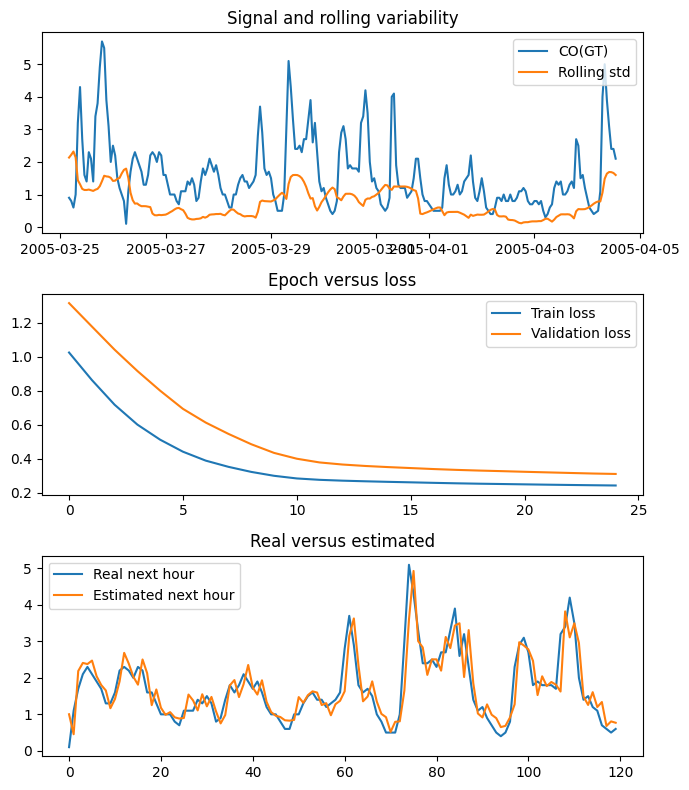

In [6]:
#@title Python Code - Rolling Variability

# Rolling variability shows local signal stability.
# This example uses air quality data.
# Small dense models support quick forecasting.

# !pip install tensorflow==2.20.0

# Download this dataset in Colab first.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
# Then unzip the downloaded archive.

!unzip -o AirQualityUCI.zip

# Import core libraries for analysis.
import os, warnings, random
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

# Silence TensorFlow warning messages.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.metrics import mean_absolute_error

# Reduce TensorFlow console noise.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Print one short framework line.
print('TensorFlow version:', tf.__version__)

# Load the air quality file.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Build a proper datetime index.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace dataset missing value marker.
df = df.replace(-200, np.nan)
df = df.dropna(subset=['DateTime', 'CO(GT)'])

df = df.sort_values('DateTime')
df = df.set_index('DateTime')

# Keep one signal for teaching.
signal = df['CO(GT)'].astype(float)
signal = signal.interpolate(limit_direction='both')

signal = signal.resample('h').mean()
signal = signal.interpolate(limit_direction='both')

# Create rolling variability features.
work = pd.DataFrame()
work['co'] = signal

work['co_roll_std_3'] = work['co'].rolling(3).std()
work['co_roll_std_12'] = work['co'].rolling(12).std()

# Create simple forecasting features.
work['co_lag_1'] = work['co'].shift(1)
work['co_lag_3'] = work['co'].shift(3)

work['target_next'] = work['co'].shift(-1)
work = work.dropna().copy()

# Explain why variability matters locally.
print('Rolling standard deviation tracks short-term instability.')
print('Higher local variability can indicate changing conditions.')

# Select a small recent subset.
work = work.tail(1500).copy()
features = ['co', 'co_lag_1', 'co_lag_3']

features += ['co_roll_std_3', 'co_roll_std_12']

# Split data in time order.
n_total = len(work)
train_end = int(n_total * 0.7)

val_end = int(n_total * 0.85)
train_df = work.iloc[:train_end].copy()
val_df = work.iloc[train_end:val_end].copy()

test_df = work.iloc[val_end:].copy()

# Compute scaling from training only.
X_train = train_df[features].to_numpy()
X_val = val_df[features].to_numpy()

X_test = test_df[features].to_numpy()

y_train = train_df['target_next'].to_numpy().reshape(-1, 1)
y_val = val_df['target_next'].to_numpy().reshape(-1, 1)
y_test = test_df['target_next'].to_numpy().reshape(-1, 1)

# Standardize inputs with safe values.
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_std[X_std == 0] = 1.0
X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std

X_test = (X_test - X_mean) / X_std

# Standardize targets for training.
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)

y_std[y_std == 0] = 1.0
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std

# Build a small dense network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(features),)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the forecasting model.
model.compile(
    optimizer='adam',

    loss='mse')

# Train quietly with validation.
history = model.fit(
    X_train, y_train_s,

    validation_data=(X_val, y_val_s),
    epochs=25, verbose=0)

# Predict and invert scaling.
pred_s = model.predict(X_test, verbose=0)
pred = pred_s * y_std + y_mean

mae = mean_absolute_error(y_test.ravel(), pred.ravel())

# Print one short evaluation line.
print('Test MAE:', round(float(mae), 3))

# Plot variability, loss, and estimates.
fig, axes = plt.subplots(3, 1, figsize=(7, 8))

# Show signal and rolling variability.
axes[0].plot(work.index[-250:], work['co'][-250:], label='CO(GT)')
axes[0].plot(work.index[-250:], work['co_roll_std_12'][-250:], label='Rolling std')

axes[0].set_title('Signal and rolling variability')
axes[0].legend()

# Show training and validation loss.
axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')

axes[1].set_title('Epoch versus loss')
axes[1].legend()

# Show real and estimated values.
axes[2].plot(y_test[:120], label='Real next hour')
axes[2].plot(pred[:120], label='Estimated next hour')

axes[2].set_title('Real versus estimated')
axes[2].legend()

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **2.3. Change Rate Features**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_02_03.jpg?v=1776653865" width="250">



>* Change rates reveal trends hidden by levels.
>* They help detect gradual shifts and sudden events.

>* Change rates show motion, not just levels.
>* Choose intervals to match process timescales.

>* Change rates need context and smoothing.
>* They reveal momentum, turning points, acceleration.



--2026-04-19 23:13:47--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.4’

AirQualityUCI.zip.4     [  <=>               ]   1.47M  4.05MB/s    in 0.4s    

2026-04-19 23:13:48 (4.05 MB/s) - ‘AirQualityUCI.zip.4’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Rows after cleaning: 1497
Rate features highlight rapid sensor shifts.
Large positive differences mean sudden increases.
Test MAE: 0.469
Test RMSE: 0.619


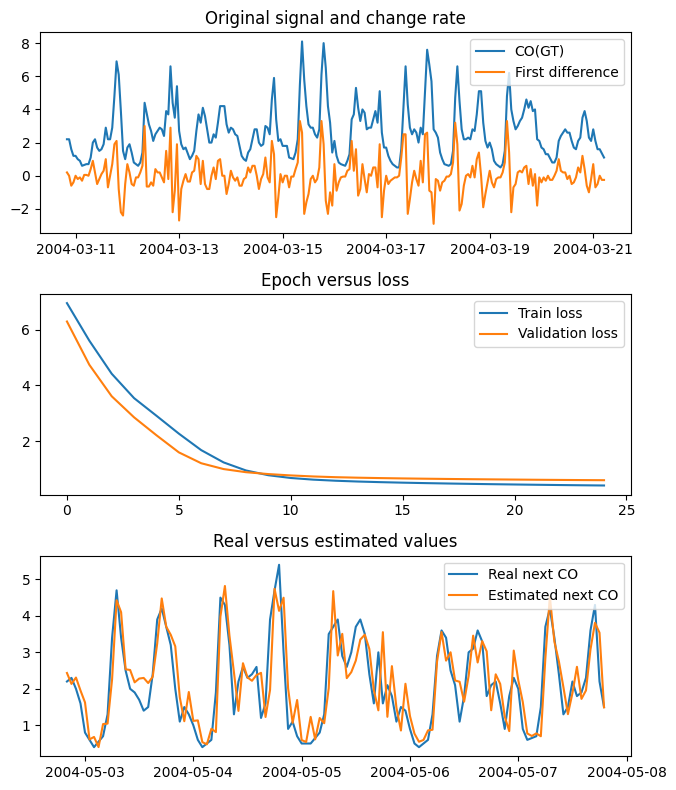

In [7]:
#@title Python Code - Change Rate Features

# Download the air quality dataset first.
# Build change rate features from sensor data.
# Train a small temporal prediction model.

# !pip install tensorflow==2.20.0

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

!unzip -o AirQualityUCI.zip

# Import quiet libraries for Colab use.
import os, warnings, random, zipfile
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

# Silence TensorFlow warning messages.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Import simple regression metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Print one short framework line.
print('TensorFlow version:', tf.__version__)

# Load the semicolon separated file.
file_name = 'AirQualityUCI.csv'
df = pd.read_csv(file_name, sep=';', decimal=',')

# Remove empty trailing columns safely.
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Combine date and time columns.
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace missing value code with NaN.
df = df.replace(-200, np.nan)
df = df.sort_values('DateTime')

# Keep useful columns for teaching.
keep_cols = ['DateTime', 'CO(GT)', 'PT08.S1(CO)', 'T']
df = df[keep_cols].copy()

# Drop rows with missing timestamps.
df = df.dropna(subset=['DateTime'])
df = df.set_index('DateTime')

# Resample to regular hourly spacing.
df = df.resample('h').mean()
df = df.interpolate(limit_direction='both')

# Keep a manageable clean subset.
df = df.dropna().iloc[:1500].copy()

# Create first difference features.
df['co_diff_1'] = df['CO(GT)'].diff()
df['temp_diff_1'] = df['T'].diff()

# Create relative change rate feature.
df['co_rate_pct'] = (
    df['CO(GT)'].pct_change() * 100.0)

# Create lagged predictor features.
df['co_lag_1'] = df['CO(GT)'].shift(1)
df['co_lag_2'] = df['CO(GT)'].shift(2)

df['temp_lag_1'] = df['T'].shift(1)

# Predict the next carbon monoxide value.
df['target_next_co'] = df['CO(GT)'].shift(-1)
df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna().copy()

# Explain sudden changes briefly.
print('Rows after cleaning:', len(df))
print('Rate features highlight rapid sensor shifts.')

print('Large positive differences mean sudden increases.')

# Select beginner friendly model inputs.
feature_cols = [
    'co_lag_1', 'co_lag_2', 'temp_lag_1',

    'co_diff_1', 'temp_diff_1', 'co_rate_pct']
X = df[feature_cols].to_numpy(dtype='float32')
y = df['target_next_co'].to_numpy(dtype='float32')

# Check data sizes before training.
if len(X) < 200:
    raise ValueError('Not enough rows for training.')

# Split chronologically to avoid leakage.
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y[:train_end]
y_val = y[train_end:val_end]
y_test = y[val_end:]

# Standardize using training statistics only.
mean_x = X_train.mean(axis=0)
std_x = X_train.std(axis=0) + 1e-6

X_train = (X_train - mean_x) / std_x
X_val = (X_val - mean_x) / std_x
X_test = (X_test - mean_x) / std_x

# Build a very small dense model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the regression model.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Train quietly with validation data.
history = model.fit(
    X_train, y_train,

    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=32,

    verbose=0)

# Predict on the test period.
y_pred = model.predict(X_test, verbose=0).flatten()
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Print compact evaluation results.
print('Test MAE:', round(float(mae), 3))
print('Test RMSE:', round(float(rmse), 3))

# Prepare aligned plotting data.
plot_df = df.iloc[val_end:].copy()
plot_df = plot_df.iloc[:len(y_test)].copy()

plot_df['predicted_next_co'] = y_pred

# Create three teaching plots together.
fig, axes = plt.subplots(3, 1, figsize=(7, 8))

# Plot original series and change rate.
axes[0].plot(df.index[:250], df['CO(GT)'][:250], label='CO(GT)')
axes[0].plot(df.index[:250], df['co_diff_1'][:250], label='First difference')

axes[0].set_title('Original signal and change rate')
axes[0].legend()

# Plot epoch versus training losses.
axes[1].plot(history.history['loss'], label='Train loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')

axes[1].set_title('Epoch versus loss')
axes[1].legend()

# Plot real versus estimated values.
axes[2].plot(plot_df.index[:120], y_test[:120], label='Real next CO')
axes[2].plot(

    plot_df.index[:120],
    plot_df['predicted_next_co'][:120],
    label='Estimated next CO')

axes[2].set_title('Real versus estimated values')
axes[2].legend()

# Show the final teaching figure.
plt.tight_layout()
plt.show()

## **3. Time aware splits**

### **3.1. Time Block Splits**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_03_01.jpg?v=1776653933" width="250">



>* Train on earlier data, validate later.
>* Preserves order for realistic future testing.

>* Block splits test changing future conditions.
>* Random mixing can overestimate model performance.

>* Choose block lengths matching process timescales.
>* Align periods carefully for realistic evaluation.



TensorFlow version: 2.21.0
Rows used: 2500
Train rows: 2000 Test rows: 500
Time blocking avoids future information leaking backward.
Random shuffling would mix past and future conditions.
Test MAE: 0.64
Test RMSE: 0.885


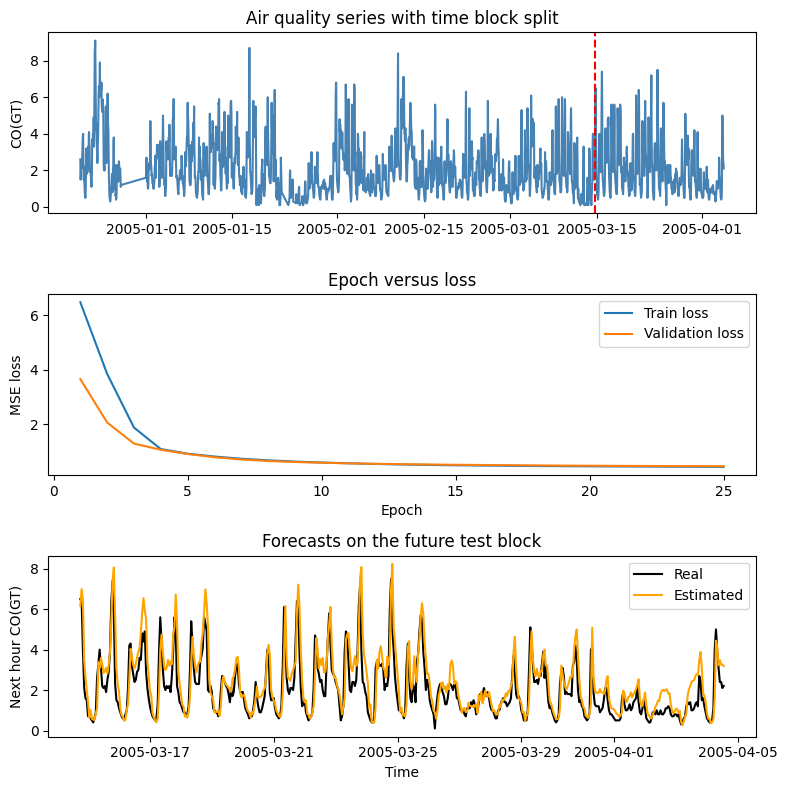

In [9]:
#@title Python Code - Time Block Splits

# Time block splits preserve real forecasting order.
# This example uses air quality sensor data.
# We avoid leakage with contiguous time blocks.

# !pip install tensorflow==2.20.0

# Run this first in another cell.
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Import quiet libraries for Colab.
import os, warnings, zipfile, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Import TensorFlow and metrics.
import tensorflow as tf
from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error
tf.get_logger().setLevel('ERROR')

# Set deterministic random seeds.
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)
print('TensorFlow version:', tf.__version__)

# Unzip the downloaded dataset.
zip_path = 'AirQualityUCI.zip'
with_zip = zipfile.ZipFile(zip_path, 'r')

with_zip.extractall('.')
with_zip.close()

# Load the semicolon separated file.
file_path = 'AirQualityUCI.csv'
df = pd.read_csv(file_path, sep=';', decimal=',')

df = df.dropna(axis=1, how='all')
df = df.dropna(axis=0, how='all')

# Build a proper datetime index.
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace missing value markers.
df = df.dropna(subset=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

df = df.replace(-200, np.nan)

# Keep a few useful columns.
keep_cols = ['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'T', 'RH']
df = df[keep_cols].copy()

df = df.set_index('Datetime')

# Resample to regular hourly data.
df = df.resample('1h').mean()
df = df.interpolate(limit_direction='both')

# Create a forecasting target.
df['target_next_co'] = df['CO(GT)'].shift(-1)
df['co_lag_1'] = df['CO(GT)'].shift(1)

df['co_lag_24'] = df['CO(GT)'].shift(24)
df['co_roll_mean_6'] = df['CO(GT)'].rolling(6).mean()

# Add simple rate features.
df['temp_change_1'] = df['T'].diff(1)
df['rh_roll_mean_6'] = df['RH'].rolling(6).mean()

df['sensor_roll_mean_6'] = df['PT08.S1(CO)'].rolling(6).mean()
df = df.dropna().copy()

# Keep a small recent subset.
max_rows = 2500
if len(df) > max_rows:

    df = df.iloc[-max_rows:].copy()

# Select features and target.
feature_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'T', 'RH',

    'co_lag_1', 'co_lag_24', 'co_roll_mean_6',
    'temp_change_1', 'rh_roll_mean_6', 'sensor_roll_mean_6']
X = df[feature_cols].copy()

y = df['target_next_co'].copy()

# Split using contiguous time blocks.
split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index].copy()

X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Explain why blocking matters.
print('Rows used:', len(df))
print('Train rows:', len(X_train), 'Test rows:', len(X_test))

print('Time blocking avoids future information leaking backward.')
print('Random shuffling would mix past and future conditions.')

# Standardize using training statistics only.
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

# Convert to numpy arrays.
X_train_np = X_train_scaled.to_numpy(dtype=np.float32)
X_test_np = X_test_scaled.to_numpy(dtype=np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

# Build a small dense model.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_np.shape[1],)),

    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)])

# Compile the forecasting model.
model.compile(
    optimizer='adam',

    loss='mse',
    metrics=['mae'])

# Train silently with validation split.
history = model.fit(
    X_train_np, y_train_np,

    epochs=25,
    batch_size=32,
    validation_split=0.2,

    verbose=0)

# Predict on the future block.
y_pred = model.predict(X_test_np, verbose=0).flatten()
mae = mean_absolute_error(y_test_np, y_pred)

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
print('Test MAE:', round(float(mae), 3))
print('Test RMSE:', round(float(rmse), 3))

# Prepare values for plotting.
split_time = df.index[split_index]
loss_values = history.history['loss']

val_loss_values = history.history['val_loss']
epochs = np.arange(1, len(loss_values) + 1)

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
axes[0].plot(df.index, df['CO(GT)'], color='steelblue')

axes[0].axvline(split_time, color='red', linestyle='--')
axes[0].set_title('Air quality series with time block split')
axes[0].set_ylabel('CO(GT)')

# Plot training history.
axes[1].plot(epochs, loss_values, label='Train loss')
axes[1].plot(epochs, val_loss_values, label='Validation loss')

axes[1].set_title('Epoch versus loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE loss')

axes[1].legend()

# Plot real and estimated test forecasts.
axes[2].plot(y_test.index, y_test_np, label='Real', color='black')
axes[2].plot(y_test.index, y_pred, label='Estimated', color='orange')

axes[2].set_title('Forecasts on the future test block')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Next hour CO(GT)')

# Finish the single required figure.
axes[2].legend()
plt.tight_layout()

plt.show()

### **3.2. Rolling Validation**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_03_02.jpg?v=1776654118" width="250">



>* Train earlier, validate later as time moves.
>* Prevents leakage and mirrors real forecasting.

>* Shows performance changes across time periods.
>* Tests robustness under changing civil conditions.

>* Match validation windows to forecasting use.
>* Train earlier, validate later, assess reliability.



--2026-04-19 23:17:18--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.6’

AirQualityUCI.zip.6     [  <=>               ]   1.47M  4.06MB/s    in 0.4s    

2026-04-19 23:17:19 (4.06 MB/s) - ‘AirQualityUCI.zip.6’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      
TensorFlow version: 2.21.0
Rows used: 1200
Number of folds: 5
Average MAE: 0.24


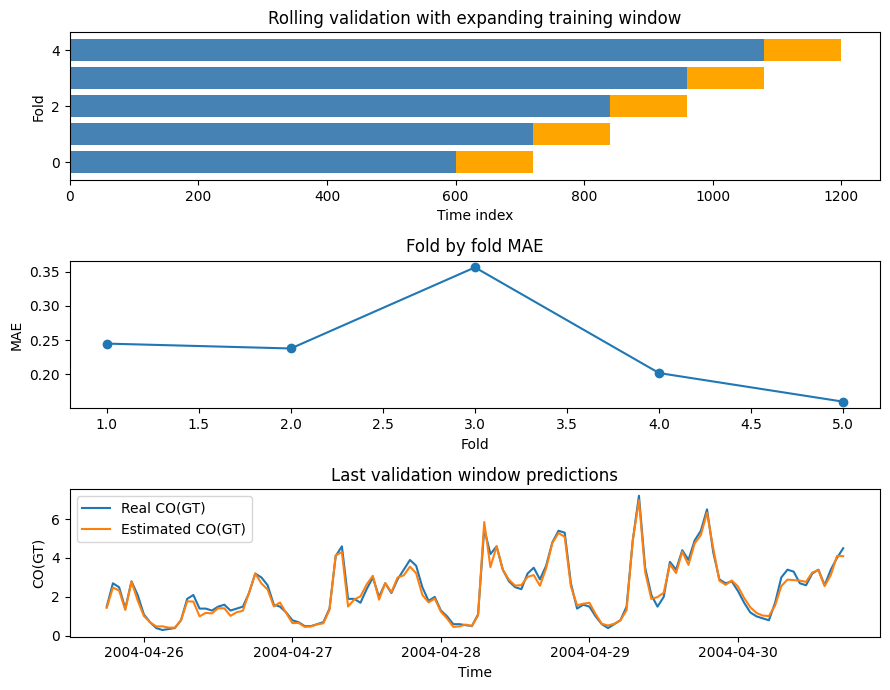

In [11]:
#@title Python Code - Rolling Validation

# Rolling validation respects time order.
# This example uses air quality data.
# Expanding windows mimic real forecasting.

# !pip install tensorflow==2.20.0

# Download the dataset in Colab.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded archive.
!unzip -o AirQualityUCI.zip

# Silence TensorFlow warning messages.
import os, warnings, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

# Import plotting and metrics tools.
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

import tensorflow as tf

# Reduce TensorFlow console noise.
tf.get_logger().setLevel('ERROR')
np.random.seed(7)

random.seed(7)
tf.random.set_seed(7)

# Print one short framework line.
print('TensorFlow version:', tf.__version__)

# Load the semicolon separated file.
df = pd.read_csv(
    'AirQualityUCI.csv',

    sep=';',
    decimal=',')

# Remove empty unnamed columns.
df = df.loc[:, ~df.columns.str.contains('Unnamed')]
df = df.dropna(how='all')

df = df[df['Date'].notna()]
df = df[df['Time'].notna()]

# Build a proper datetime index.
df['timestamp'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

df = df.dropna(subset=['timestamp'])
df = df.sort_values('timestamp')
df = df.set_index('timestamp')

# Replace missing markers with NaN.
for col in df.columns:
    if col not in ['Date', 'Time']:

        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace(-200, np.nan)

# Keep one target and simple predictors.
keep = ['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']
df = df[keep].copy()

df = df.interpolate(limit_direction='both')
df = df.dropna()

# Resample to a regular hourly grid.
df = df.resample('1h').mean()
df = df.interpolate(limit_direction='both')

# Create beginner friendly lag features.
df['co_lag1'] = df['CO(GT)'].shift(1)
df['co_lag24'] = df['CO(GT)'].shift(24)

df['temp_lag1'] = df['T'].shift(1)
df['rh_lag1'] = df['RH'].shift(1)

# Add simple rolling features.
df['co_ma6'] = df['CO(GT)'].rolling(6).mean()
df['co_change1'] = df['CO(GT)'].diff(1)

df = df.dropna().copy()

# Limit size for fast classroom runtime.
df = df.iloc[:1200].copy()
features = [

    'PT08.S1(CO)', 'T', 'RH', 'co_lag1',
    'co_lag24', 'temp_lag1', 'rh_lag1', 'co_ma6',
    'co_change1']

# Prepare arrays for modeling.
X_all = df[features].to_numpy(dtype='float32')
y_all = df['CO(GT)'].to_numpy(dtype='float32')

time_all = df.index.to_numpy()

# Define expanding rolling windows.
train_size = 600
val_size = 120

step_size = 120
starts = []

# Collect fold starting positions.
start = train_size
while start + val_size <= len(df):

    starts.append(start)
    start = start + step_size

# Store fold results for plots.
fold_mae = []
fold_ranges = []

last_true = None
last_pred = None
last_time = None

# Create a small dense model.
def make_model(input_dim):
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),

        tf.keras.layers.Dense(1)])

    model.compile(
        optimizer='adam',
        loss='mse')

    return model

# Run walk forward validation.
for fold_id in range(len(starts)):
    split = starts[fold_id]

    end = split + val_size
    X_train = X_all[:split]
    y_train = y_all[:split]

    X_val = X_all[split:end]
    y_val = y_all[split:end]

    # Scale using training statistics only.
    x_mean = X_train.mean(axis=0)
    x_std = X_train.std(axis=0) + 1e-6

    y_mean = y_train.mean()
    y_std = y_train.std() + 1e-6

    X_train_s = (X_train - x_mean) / x_std
    X_val_s = (X_val - x_mean) / x_std
    y_train_s = (y_train - y_mean) / y_std

    # Fit quietly on past data only.
    model = make_model(X_train_s.shape[1])
    model.fit(

        X_train_s, y_train_s,
        epochs=20,
        batch_size=32,

        verbose=0)

    # Predict the next time block.
    pred_s = model.predict(X_val_s, verbose=0).reshape(-1)
    pred = pred_s * y_std + y_mean

    mae = mean_absolute_error(y_val, pred)

    # Save fold summaries.
    fold_mae.append(mae)
    fold_ranges.append((0, split, split, end))

    last_true = y_val.copy()
    last_pred = pred.copy()
    last_time = time_all[split:end]

# Print a short summary only.
print('Rows used:', len(df))
print('Number of folds:', len(fold_mae))

print('Average MAE:', round(float(np.mean(fold_mae)), 3))

# Create one figure with three panels.
fig, axes = plt.subplots(3, 1, figsize=(9, 7))

# Draw the rolling fold diagram.
for i in range(len(fold_ranges)):
    a, b, c, d = fold_ranges[i]

    axes[0].barh(i, b - a, left=a, color='steelblue')
    axes[0].barh(i, d - c, left=c, color='orange')

axes[0].set_title('Rolling validation with expanding training window')
axes[0].set_xlabel('Time index')
axes[0].set_ylabel('Fold')

# Plot fold by fold validation error.
axes[1].plot(range(1, len(fold_mae) + 1), fold_mae, marker='o')
axes[1].set_title('Fold by fold MAE')

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAE')

# Plot real versus estimated values.
axes[2].plot(last_time, last_true, label='Real CO(GT)')
axes[2].plot(last_time, last_pred, label='Estimated CO(GT)')

axes[2].set_title('Last validation window predictions')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('CO(GT)')

# Finish the single teaching figure.
axes[2].legend()
plt.tight_layout()

plt.show()

### **3.3. Leakage Prevention**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_10/Lecture_A/image_03_03.jpg?v=1776654161" width="250">



>* Leakage uses future data, distorting evaluation.
>* It inflates accuracy but fails in practice.

>* Keep splits and preprocessing strictly chronological.
>* Check every feature matches prediction-time availability.

>* Think live: use only past information.
>* Time-separated preprocessing prevents leakage, builds trust.



--2026-04-19 23:24:23--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.14’

AirQualityUCI.zip.1     [   <=>              ]   1.47M  2.45MB/s    in 0.6s    

2026-04-19 23:24:24 (2.45 MB/s) - ‘AirQualityUCI.zip.14’ saved [1543989]

TensorFlow version: 2.21.0
Train rows: 1530 Validation rows: 383
Honest MAE: 0.561 RMSE: 0.698
Leaked MAE: 0.291 RMSE: 0.431
Lower leaked error looks better, but is dishonest.


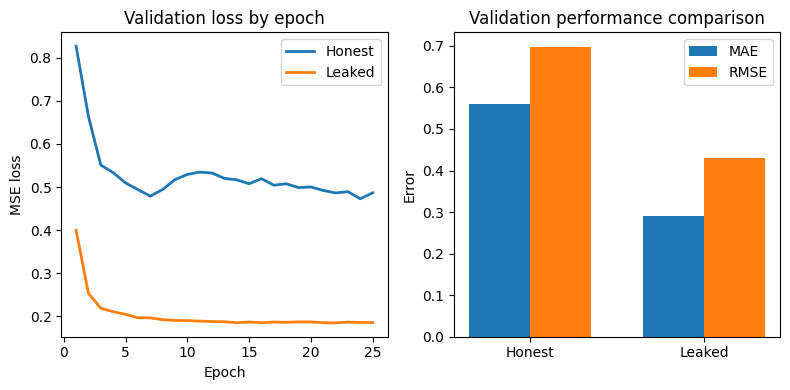

In [20]:
#@title Python Code - Leakage Prevention

# This cell downloads the air dataset.
# Run this cell before modeling steps.
# It matches the lecture download instruction.

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# This example shows leakage prevention.
# It compares honest and leaked pipelines.
# Civil engineering sensors need time order.

# import tensorflow==2.20.0

import os, warnings, zipfile, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.get_logger().setLevel('ERROR')
np.random.seed(7)
random.seed(7)

tf.random.set_seed(7)

# Show framework version briefly.
print('TensorFlow version:', tf.__version__)

# Unzip the downloaded dataset safely.
zip_path = 'AirQualityUCI.zip'
if os.path.exists(zip_path):

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall('.')

# Load the semicolon separated file.
file_path = 'AirQualityUCI.csv'
df = pd.read_csv(file_path, sep=';', decimal=',')

# Remove empty trailing columns.
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')

# Build a proper datetime column.
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],

    format='%d/%m/%Y %H.%M.%S',
    errors='coerce')

# Replace dataset missing markers.
df = df.replace(-200, np.nan)
df = df.sort_values('Datetime').reset_index(drop=True)

# Keep a small clean subset.
keep_cols = ['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'T', 'RH']
df = df[keep_cols].dropna().copy()

df = df.iloc[:1500].copy()

# Rename columns for easier teaching.
df.columns = ['time', 'target_co', 'sensor_s1', 'temp', 'rh']
df = df.set_index('time').asfreq('h')

# Fill gaps using past information only.
df = df.ffill()
df = df.dropna().copy()

# Create honest past-only features.
df['co_lag1'] = df['target_co'].shift(1)
df['co_roll3_past'] = df['target_co'].shift(1).rolling(3).mean()

df['sensor_lag1'] = df['sensor_s1'].shift(1)
df['temp_lag1'] = df['temp'].shift(1)

# Create an intentionally leaked feature.
df['co_future_1h'] = df['target_co'].shift(-1)

# Drop rows with missing engineered values.
df = df.dropna().copy()

# Use a chronological train validation split.
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()

valid_df = df.iloc[split_index:].copy()

# Define feature sets for both pipelines.
good_features = ['co_lag1', 'co_roll3_past', 'sensor_lag1', 'temp_lag1', 'rh']
bad_features = ['co_lag1', 'co_roll3_past', 'sensor_lag1', 'temp_lag1', 'rh', 'co_future_1h']

# Fit scaling using training period only.
train_mean_good = train_df[good_features].mean()
train_std_good = train_df[good_features].std().replace(0, 1)

train_mean_bad = train_df[bad_features].mean()
train_std_bad = train_df[bad_features].std().replace(0, 1)

y_train = train_df['target_co'].to_numpy(dtype='float32')
y_valid = valid_df['target_co'].to_numpy(dtype='float32')

X_train_good = ((train_df[good_features] - train_mean_good) / train_std_good).to_numpy(dtype='float32')
X_valid_good = ((valid_df[good_features] - train_mean_good) / train_std_good).to_numpy(dtype='float32')
X_train_bad = ((train_df[bad_features] - train_mean_bad) / train_std_bad).to_numpy(dtype='float32')

X_valid_bad = ((valid_df[bad_features] - train_mean_bad) / train_std_bad).to_numpy(dtype='float32')

# Check shapes before training.
assert len(X_train_good) > 100 and len(X_valid_good) > 20
assert X_train_good.shape[1] == len(good_features)

assert X_train_bad.shape[1] == len(bad_features)

# Build a small dense model.
def make_model(input_dim):
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),

        tf.keras.layers.Dense(1)])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),

        loss='mse')
    return model

# Train the honest pipeline.
model_good = make_model(X_train_good.shape[1])
history_good = model_good.fit(

    X_train_good, y_train,
    validation_data=(X_valid_good, y_valid),
    epochs=25, batch_size=32, verbose=0)

# Train the leaked pipeline.
model_bad = make_model(X_train_bad.shape[1])
history_bad = model_bad.fit(

    X_train_bad, y_train,
    validation_data=(X_valid_bad, y_valid),
    epochs=25, batch_size=32, verbose=0)

# Predict on the validation period.
pred_good = model_good.predict(X_valid_good, verbose=0).ravel()
pred_bad = model_bad.predict(X_valid_bad, verbose=0).ravel()

# Compute simple regression metrics.
mae_good = mean_absolute_error(y_valid, pred_good)
rmse_good = mean_squared_error(y_valid, pred_good) ** 0.5

mae_bad = mean_absolute_error(y_valid, pred_bad)
rmse_bad = mean_squared_error(y_valid, pred_bad) ** 0.5

# Print a short teaching summary.
print('Train rows:', len(train_df), 'Validation rows:', len(valid_df))
print('Honest MAE:', round(mae_good, 3), 'RMSE:', round(rmse_good, 3))

print('Leaked MAE:', round(mae_bad, 3), 'RMSE:', round(rmse_bad, 3))
print('Lower leaked error looks better, but is dishonest.')

# Create one figure with two panels only.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Plot epoch versus validation loss.
epochs = np.arange(1, len(history_good.history['val_loss']) + 1)

axes[0].plot(epochs, history_good.history['val_loss'], label='Honest', linewidth=2)
axes[0].plot(epochs, history_bad.history['val_loss'], label='Leaked', linewidth=2)
axes[0].set_title('Validation loss by epoch')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')
axes[0].legend()

# Plot leaked versus honest performance.
labels = ['Honest', 'Leaked']
mae_vals = [mae_good, mae_bad]

rmse_vals = [rmse_good, rmse_bad]
x = np.arange(len(labels))
width = 0.35

axes[1].bar(x - width/2, mae_vals, width, label='MAE')
axes[1].bar(x + width/2, rmse_vals, width, label='RMSE')
axes[1].set_xticks(x)

axes[1].set_xticklabels(labels)
axes[1].set_title('Validation performance comparison')
axes[1].set_ylabel('Error')

axes[1].legend()

plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Time-Series Preprocessing**</font>


In this lecture, you learned to:
- Resample irregular civil engineering time-series data to a regular time grid while handling missing values appropriately. 
- Engineer rolling window features such as moving averages and rates of change for temporal civil engineering signals. 
- Implement time-aware train-validation splits that respect temporal order and avoid leakage. 

In the next Lecture (Lecture B), we will go over 'Forecasting and Anomalies'